# MLB Pitch Sensor Modeling with PyTorch

## Project Overview

This project uses **MLB Statcast pitch-level tracking data** to build a multi-task neural network in **PyTorch**. The model uses sensor-derived pitch features such as release velocity, spin rate, release position, pitch movement, and other components.

The project has two modeling goals:

1. **Pitch type prediction**: classify the pitch type from tracking features.
2. **Whiff prediction**: estimate whether a pitch produces a swinging strike.

This project is designed to align with baseball operations analytics work involving:

- Machine learning
- Sensor/tracking data
- Player evaluation
- Pitch design
- Performance analysis
- Applied baseball research

The final section creates pitcher-level insights that can help identify pitchers with strong whiff profiles, pitch-shape traits, and model-estimated performance indicators.


## 1. Install & Import Libraries

Run the install cell once if working in a new environment such as Google Colab or a fresh local virtual environment.

The main libraries used are:

- `pybaseball` for MLB Statcast data
- `pandas` and `numpy` for data wrangling
- `scikit-learn` for preprocessing and evaluation
- `torch` for the PyTorch neural network
- `matplotlib` for visualizations


In [6]:
# Uncomment this cell if running in a fresh environment
# !pip install pybaseball pandas numpy scikit-learn torch matplotlib

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pybaseball import statcast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 2. Download MLB Statcast Data

This notebook uses `pybaseball` to pull pitch-level MLB Statcast data from Baseball Savant.

To keep the project manageable, the default date range is two weeks of the 2024 MLB regular season. You can expand the date range later once the notebook runs successfully.

**Tip:** Larger date ranges create stronger models but take longer to download and train.


In [8]:
START_DATE = "2024-04-01"
END_DATE = "2024-04-14"

raw = statcast(start_dt=START_DATE, end_dt=END_DATE)

print(raw.shape)
raw.head()


This is a large query, it may take a moment to complete


100%|██████████| 14/14 [00:09<00:00,  1.51it/s]


(53645, 119)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
2340,FF,2024-04-14,95.6,-2.29,5.73,"Jarvis, Bryce",663457,686826,field_out,hit_into_play,...,1,1.45,0.57,-0.57,41.0,10.399477,-5.938582,26.639945,42.690683,29.397655
2404,CH,2024-04-14,84.4,-2.53,5.47,"Jarvis, Bryce",663457,686826,NaN,ball,...,1,2.92,1.45,-1.45,32.1,<NA>,<NA>,<NA>,<NA>,<NA>
2504,CU,2024-04-14,83.9,-2.33,5.71,"Jarvis, Bryce",663457,686826,NaN,foul,...,1,4.18,-0.62,0.62,42.6,11.0582,1.191654,27.805358,37.931797,33.738059
2574,FF,2024-04-14,95.7,-2.25,5.68,"Jarvis, Bryce",663457,686826,NaN,foul,...,1,1.46,0.84,-0.84,38.1,5.547537,2.382254,36.535827,32.540828,28.596655
2614,CH,2024-04-14,85.3,-2.3,5.48,"Jarvis, Bryce",663457,686826,NaN,ball,...,1,2.21,1.25,-1.25,34.2,<NA>,<NA>,<NA>,<NA>,<NA>


## 3. Clean and Prepare Sensor Features

The features below are all pitch-level tracking or context variables. They include:

- Release velocity
- Spin rate
- Release extension
- Release position
- Horizontal and vertical movement
- Plate location
- Initial velocity components
- Acceleration components
- Count information

These variables allow the model to learn pitch shape, pitch movement, pitch location, and pitcher execution traits.


In [9]:
sensor_features = [
    "release_speed",
    "release_spin_rate",
    "release_extension",
    "release_pos_x",
    "release_pos_z",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "vx0",
    "vy0",
    "vz0",
    "ax",
    "ay",
    "az",
    "balls",
    "strikes"
]

metadata_cols = [
    "game_date",
    "player_name",
    "pitcher",
    "pitch_type",
    "description",
    "events"
]

needed_cols = metadata_cols + sensor_features

df = raw[needed_cols].copy()

print(df.shape)
df.head()


(53645, 23)


,game_date,player_name,pitcher,pitch_type,description,events,release_speed,release_spin_rate,release_extension,release_pos_x,...,plate_x,plate_z,vx0,vy0,vz0,ax,ay,az,balls,strikes
2340,2024-04-14,"Jarvis, Bryce",686826,FF,hit_into_play,field_out,95.6,2103,6.2,-2.29,...,-0.583162,2.784197,5.768357,-139.061364,-4.491823,-8.692114,32.449485,-17.721497,3,2
2404,2024-04-14,"Jarvis, Bryce",686826,CH,ball,NaN,84.4,2023,6.2,-2.53,...,-1.329683,2.165625,5.673405,-122.795309,-1.886687,-15.769579,24.830489,-29.090409,2,2
2504,2024-04-14,"Jarvis, Bryce",686826,CU,foul,NaN,83.9,2577,6.1,-2.33,...,-0.148588,2.013947,3.798023,-122.17451,-0.278876,5.475247,24.731011,-41.702389,2,2
2574,2024-04-14,"Jarvis, Bryce",686826,FF,foul,NaN,95.7,2224,6.1,-2.25,...,0.316043,1.893427,8.608152,-138.963842,-6.66227,-12.825835,30.395964,-17.495812,2,1
2614,2024-04-14,"Jarvis, Bryce",686826,CH,ball,NaN,85.3,2050,6.4,-2.3,...,-0.100848,1.373553,7.693694,-123.981894,-5.24025,-14.407604,23.356213,-21.86534,1,1


In [10]:
# Convert feature columns to numeric values
for col in sensor_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows missing important modeling inputs or labels
df = df.dropna(subset=sensor_features + ["pitch_type", "description", "player_name", "pitcher"])

# Keep pitch types with enough examples for model training
min_pitch_count = 300
pitch_counts = df["pitch_type"].value_counts()
common_pitch_types = pitch_counts[pitch_counts >= min_pitch_count].index.tolist()

df = df[df["pitch_type"].isin(common_pitch_types)].copy()

print(df.shape)
df["pitch_type"].value_counts()


(52801, 23)


pitch_type
FF    16682
SI     8423
SL     7780
CH     5612
FC     4530
ST     4079
CU     3204
FS     1562
KC      929
Name: count, dtype: int64

## 4. Create Targets

This project uses two supervised learning targets:

### Target 1: `pitch_type`

A multi-class classification target indicating the type of pitch thrown.

### Target 2: `whiff`

A binary target equal to 1 when the pitch generated a swinging strike.

Whiff events are defined using the Statcast `description` field:

- `swinging_strike`
- `swinging_strike_blocked`


In [11]:
whiff_descriptions = [
    "swinging_strike",
    "swinging_strike_blocked"
]

df["whiff"] = df["description"].isin(whiff_descriptions).astype(int)

print("Whiff rate:", round(df["whiff"].mean(), 4))
df[["pitch_type", "description", "whiff"]].head(10)


Whiff rate: 0.106


,pitch_type,description,whiff
2340,FF,hit_into_play,0
2404,CH,ball,0
2504,CU,foul,0
2574,FF,foul,0
2614,CH,ball,0
2689,CH,ball,0
2806,FF,called_strike,0
2898,SL,hit_into_play,0
2986,FF,called_strike,0
3116,SL,hit_into_play,0


In [12]:
pitch_summary = (
    df.groupby("pitch_type")
    .agg(
        pitches=("pitch_type", "size"),
        whiffs=("whiff", "sum"),
        whiff_rate=("whiff", "mean"),
        avg_velocity=("release_speed", "mean"),
        avg_spin=("release_spin_rate", "mean")
    )
    .sort_values("pitches", ascending=False)
)

pitch_summary


,pitches,whiffs,whiff_rate,avg_velocity,avg_spin
pitch_type,,,,,
FF,16682,1475,0.088419,93.868583,2283.447788
SI,8423,477,0.056631,92.973371,2139.896355
SL,7780,1222,0.157069,85.532391,2407.124679
CH,5612,741,0.132038,84.952602,1817.900214
FC,4530,445,0.098234,89.308786,2368.699779
ST,4079,495,0.121353,81.486247,2526.170385
CU,3204,335,0.104557,78.929806,2567.066167
FS,1562,288,0.184379,86.169334,1342.850192
KC,929,121,0.130248,81.344995,2365.193757


## 5. Train/Test Split

The data is split into training and test sets. The model trains on the training set and is evaluated on held-out test data.

The split is stratified by pitch type so the train and test sets contain a similar pitch-type distribution.


In [13]:
X = df[sensor_features].copy()
y_pitch = df["pitch_type"].copy()
y_whiff = df["whiff"].copy()

X_train, X_test, y_pitch_train, y_pitch_test, y_whiff_train, y_whiff_test = train_test_split(
    X,
    y_pitch,
    y_whiff,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_pitch
)

print(X_train.shape, X_test.shape)


(42240, 17) (10561, 17)


## 6. Scale Features and Encode Labels

Neural networks train better when numeric features are scaled.

This section:

1. Standardizes the input sensor features.
2. Encodes pitch type labels as integers.
3. Converts arrays into PyTorch tensors.


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pitch_encoder = LabelEncoder()

y_pitch_train_encoded = pitch_encoder.fit_transform(y_pitch_train)
y_pitch_test_encoded = pitch_encoder.transform(y_pitch_test)

pitch_classes = pitch_encoder.classes_
num_pitch_types = len(pitch_classes)

print("Pitch classes:", pitch_classes)
print("Number of pitch types:", num_pitch_types)


Pitch classes: ['CH' 'CU' 'FC' 'FF' 'FS' 'KC' 'SI' 'SL' 'ST']
Number of pitch types: 9


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = df[sensor_features].copy()
y_pitch = df["pitch_type"].copy()
y_whiff = df["whiff"].copy()

X_train, X_test, y_pitch_train, y_pitch_test, y_whiff_train, y_whiff_test = train_test_split(
    X,
    y_pitch,
    y_whiff,
    test_size=0.20,
    random_state=42,
    stratify=y_pitch
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pitch_encoder = LabelEncoder()

y_pitch_train_encoded = pitch_encoder.fit_transform(y_pitch_train)
y_pitch_test_encoded = pitch_encoder.transform(y_pitch_test)

In [16]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_pitch_train_tensor = torch.tensor(y_pitch_train_encoded, dtype=torch.long)
y_pitch_test_tensor = torch.tensor(y_pitch_test_encoded, dtype=torch.long)

y_whiff_train_tensor = torch.tensor(y_whiff_train.values, dtype=torch.float32).view(-1, 1)
y_whiff_test_tensor = torch.tensor(y_whiff_test.values, dtype=torch.float32).view(-1, 1)

## 7. Build PyTorch Dataset and DataLoader

The custom dataset returns:

- Sensor feature tensor
- Pitch type label
- Whiff label

The DataLoader batches the data for neural network training.


In [17]:
class PitchDataset(Dataset):
    def __init__(self, X, y_pitch, y_whiff):
        self.X = X
        self.y_pitch = y_pitch
        self.y_whiff = y_whiff

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_pitch[idx], self.y_whiff[idx]


train_dataset = PitchDataset(X_train_tensor, y_pitch_train_tensor, y_whiff_train_tensor)
test_dataset = PitchDataset(X_test_tensor, y_pitch_test_tensor, y_whiff_test_tensor)

BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(test_loader)


(83, 21)

## 8. Define Multi-Task Neural Network

This model has a shared neural network backbone and two output heads:

1. **Pitch type head**: predicts the pitch classification label.
2. **Whiff head**: predicts the probability of a whiff.

This is useful because pitch type and whiff probability are related but not identical. The shared layers learn general pitch-shape representations, while the task-specific heads learn separate outputs.


In [18]:
class PitchMultiTaskNet(nn.Module):
    def __init__(self, input_dim, num_pitch_types):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.pitch_type_head = nn.Linear(32, num_pitch_types)
        self.whiff_head = nn.Linear(32, 1)

    def forward(self, x):
        shared_representation = self.shared(x)

        pitch_logits = self.pitch_type_head(shared_representation)
        whiff_logit = self.whiff_head(shared_representation)

        return pitch_logits, whiff_logit


input_dim = X_train_tensor.shape[1]

model = PitchMultiTaskNet(
    input_dim=input_dim,
    num_pitch_types=num_pitch_types
).to(device)

model


PitchMultiTaskNet(
  (shared): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (pitch_type_head): Linear(in_features=32, out_features=9, bias=True)
  (whiff_head): Linear(in_features=32, out_features=1, bias=True)
)

## 9. Train Model

The training objective combines two losses:

- Cross-entropy loss for pitch type classification
- Binary cross-entropy loss for whiff prediction

Because pitch type prediction is usually easier than whiff prediction, the whiff loss is given extra weight.


In [19]:
pitch_loss_fn = nn.CrossEntropyLoss()
whiff_loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

EPOCHS = 20
WHIFF_LOSS_WEIGHT = 2.0

training_history = []

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0
    total_pitch_loss = 0
    total_whiff_loss = 0

    for batch_X, batch_pitch, batch_whiff in train_loader:
        batch_X = batch_X.to(device)
        batch_pitch = batch_pitch.to(device)
        batch_whiff = batch_whiff.to(device)

        optimizer.zero_grad()

        pitch_logits, whiff_logit = model(batch_X)

        pitch_loss = pitch_loss_fn(pitch_logits, batch_pitch)
        whiff_loss = whiff_loss_fn(whiff_logit, batch_whiff)

        loss = pitch_loss + WHIFF_LOSS_WEIGHT * whiff_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_pitch_loss += pitch_loss.item()
        total_whiff_loss += whiff_loss.item()

    avg_loss = total_loss / len(train_loader)
    avg_pitch_loss = total_pitch_loss / len(train_loader)
    avg_whiff_loss = total_whiff_loss / len(train_loader)

    training_history.append({
        "epoch": epoch + 1,
        "loss": avg_loss,
        "pitch_loss": avg_pitch_loss,
        "whiff_loss": avg_whiff_loss
    })

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Loss: {avg_loss:.4f} | "
        f"Pitch Loss: {avg_pitch_loss:.4f} | "
        f"Whiff Loss: {avg_whiff_loss:.4f}"
    )

history_df = pd.DataFrame(training_history)
history_df


Epoch 01 | Loss: 2.2553 | Pitch Loss: 1.3351 | Whiff Loss: 0.4601
Epoch 02 | Loss: 1.2992 | Pitch Loss: 0.6251 | Whiff Loss: 0.3371
Epoch 03 | Loss: 1.1874 | Pitch Loss: 0.5251 | Whiff Loss: 0.3311
Epoch 04 | Loss: 1.1517 | Pitch Loss: 0.4919 | Whiff Loss: 0.3299
Epoch 05 | Loss: 1.1255 | Pitch Loss: 0.4687 | Whiff Loss: 0.3284
Epoch 06 | Loss: 1.1077 | Pitch Loss: 0.4549 | Whiff Loss: 0.3264
Epoch 07 | Loss: 1.0974 | Pitch Loss: 0.4491 | Whiff Loss: 0.3241
Epoch 08 | Loss: 1.0859 | Pitch Loss: 0.4426 | Whiff Loss: 0.3216
Epoch 09 | Loss: 1.0802 | Pitch Loss: 0.4380 | Whiff Loss: 0.3211
Epoch 10 | Loss: 1.0672 | Pitch Loss: 0.4294 | Whiff Loss: 0.3189
Epoch 11 | Loss: 1.0630 | Pitch Loss: 0.4253 | Whiff Loss: 0.3188
Epoch 12 | Loss: 1.0566 | Pitch Loss: 0.4223 | Whiff Loss: 0.3171
Epoch 13 | Loss: 1.0531 | Pitch Loss: 0.4175 | Whiff Loss: 0.3178
Epoch 14 | Loss: 1.0488 | Pitch Loss: 0.4140 | Whiff Loss: 0.3174
Epoch 15 | Loss: 1.0384 | Pitch Loss: 0.4076 | Whiff Loss: 0.3154
Epoch 16 |

,epoch,loss,pitch_loss,whiff_loss
0,1,2.255292,1.335124,0.460084
1,2,1.299248,0.625102,0.337073
2,3,1.187374,0.525122,0.331126
3,4,1.151749,0.491927,0.329911
4,5,1.125482,0.468676,0.328403
5,6,1.107735,0.454894,0.326421
6,7,1.097370,0.449092,0.324139
7,8,1.085893,0.442647,0.321623
8,9,1.080165,0.437984,0.321090
9,10,1.067198,0.429448,0.318875


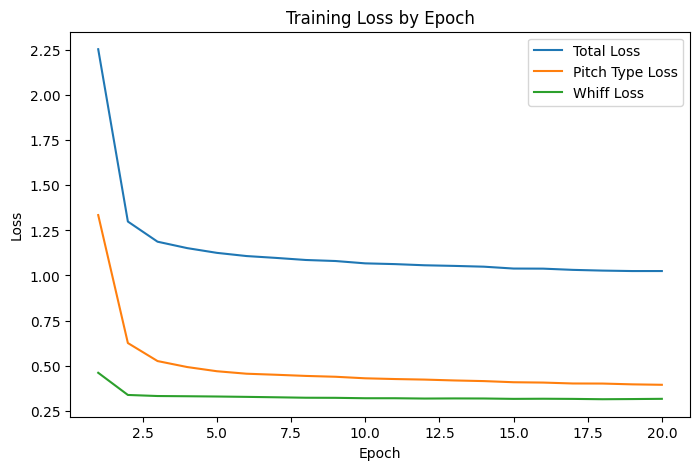

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["loss"], label="Total Loss")
plt.plot(history_df["epoch"], history_df["pitch_loss"], label="Pitch Type Loss")
plt.plot(history_df["epoch"], history_df["whiff_loss"], label="Whiff Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss by Epoch")
plt.legend()
plt.show()


## 10. Evaluate Pitch Type Prediction

This section evaluates how well the model identifies pitch type from sensor/tracking features.

Metrics include:

- Overall accuracy
- Classification report
- Confusion matrix


In [28]:
model.eval()

all_pitch_true = []
all_pitch_pred = []
all_whiff_true = []
all_whiff_prob = []

with torch.no_grad():
    for batch_X, batch_pitch, batch_whiff in test_loader:
        batch_X = batch_X.to(device)

        pitch_logits, whiff_logit = model(batch_X)

        pitch_pred = torch.argmax(pitch_logits, dim=1).cpu().numpy()
        whiff_prob = torch.sigmoid(whiff_logit).cpu().numpy().ravel()

        all_pitch_true.extend(batch_pitch.cpu().numpy())
        all_pitch_pred.extend(pitch_pred)
        all_whiff_true.extend(batch_whiff.cpu().numpy().ravel())
        all_whiff_prob.extend(whiff_prob)

all_pitch_true = np.array(all_pitch_true)
all_pitch_pred = np.array(all_pitch_pred)
all_whiff_true = np.array(all_whiff_true)
all_whiff_prob = np.array(all_whiff_prob)

print("X_test rows:", len(X_test))
print("Predictions:", len(all_pitch_pred))
print("Whiff probabilities:", len(all_whiff_prob))

X_test rows: 10561
Predictions: 10561
Whiff probabilities: 10561


In [29]:
pitch_accuracy = accuracy_score(all_pitch_true, all_pitch_pred)

print("Pitch Type Accuracy:", round(pitch_accuracy, 4))
print()
print(classification_report(
    all_pitch_true,
    all_pitch_pred,
    target_names=pitch_classes
))


Pitch Type Accuracy: 0.8568

              precision    recall  f1-score   support

          CH       0.88      0.90      0.89      1122
          CU       0.77      0.81      0.79       641
          FC       0.76      0.70      0.73       906
          FF       0.94      0.95      0.94      3337
          FS       0.82      0.63      0.71       312
          KC       0.64      0.37      0.46       186
          SI       0.90      0.89      0.89      1685
          SL       0.78      0.79      0.78      1556
          ST       0.78      0.89      0.83       816

    accuracy                           0.86     10561
   macro avg       0.81      0.77      0.78     10561
weighted avg       0.86      0.86      0.85     10561



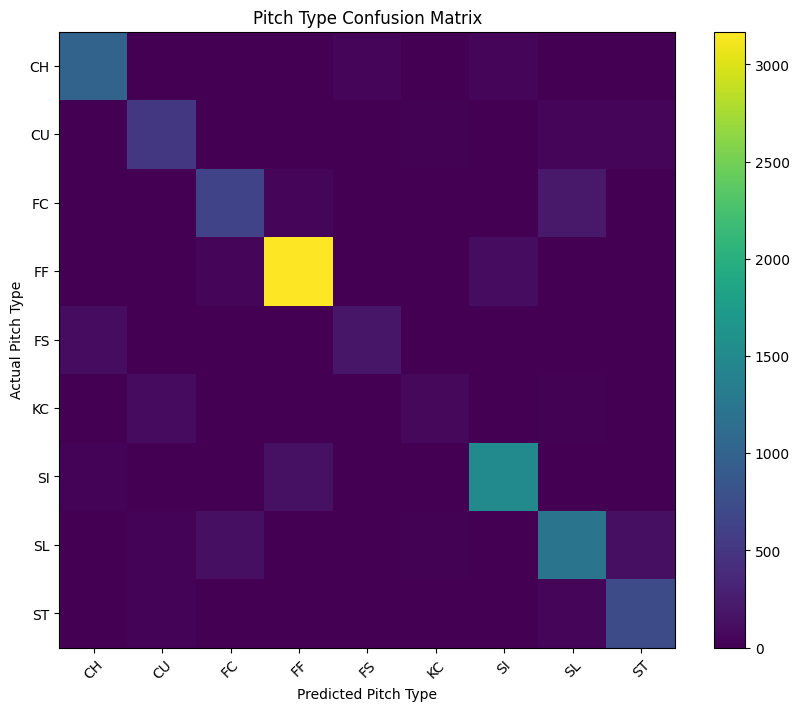

In [30]:
cm = confusion_matrix(all_pitch_true, all_pitch_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Pitch Type Confusion Matrix")
plt.xlabel("Predicted Pitch Type")
plt.ylabel("Actual Pitch Type")
plt.xticks(range(len(pitch_classes)), pitch_classes, rotation=45)
plt.yticks(range(len(pitch_classes)), pitch_classes)
plt.colorbar()
plt.show()


## 11. Evaluate Whiff Prediction

This section evaluates the model's ability to estimate whiff probability.

Metrics include:

- ROC AUC
- Average precision
- Precision-recall curve
- ROC curve

Whiff prediction is usually more difficult than pitch type prediction because a whiff depends on the hitter, count, pitch sequencing, location, pitch quality, and swing decision.


In [31]:
whiff_auc = roc_auc_score(all_whiff_true, all_whiff_prob)
whiff_avg_precision = average_precision_score(all_whiff_true, all_whiff_prob)

print("Whiff ROC AUC:", round(whiff_auc, 4))
print("Whiff Average Precision:", round(whiff_avg_precision, 4))
print("Baseline Whiff Rate:", round(all_whiff_true.mean(), 4))


Whiff ROC AUC: 0.7179
Whiff Average Precision: 0.2159
Baseline Whiff Rate: 0.1067


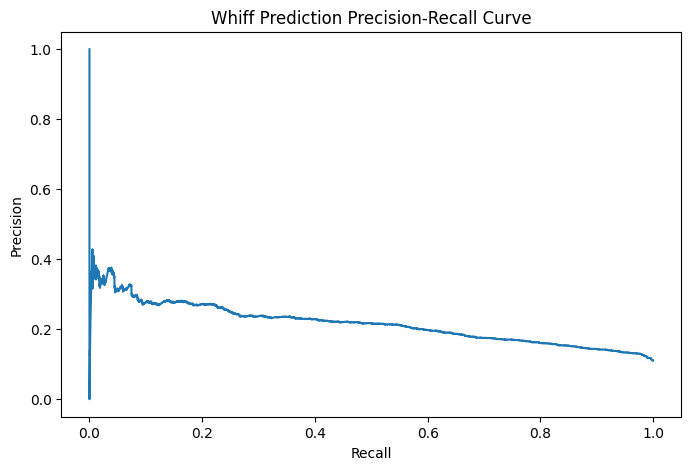

In [32]:
precision, recall, thresholds = precision_recall_curve(all_whiff_true, all_whiff_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Whiff Prediction Precision-Recall Curve")
plt.show()


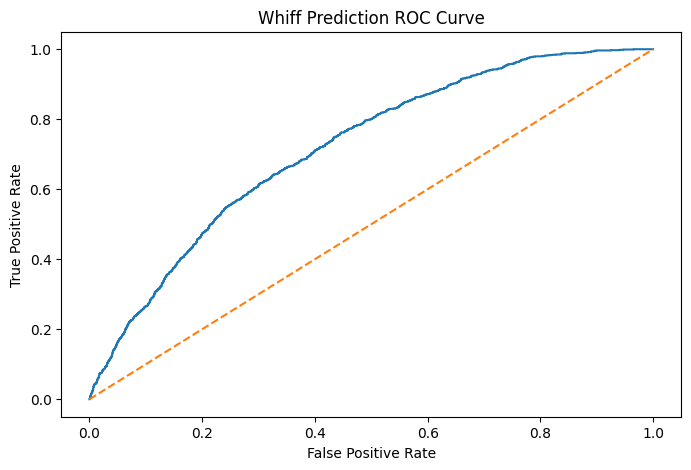

In [33]:
fpr, tpr, roc_thresholds = roc_curve(all_whiff_true, all_whiff_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Whiff Prediction ROC Curve")
plt.show()


## 12. Pitcher-Level Insights

This section converts pitch-level predictions into pitcher-level summaries.

For each pitcher, we calculate:

- Number of pitches
- Actual whiff rate
- Model-estimated whiff probability
- Average velocity
- Average spin rate
- Primary pitch type

This creates a player evaluation table that can help identify pitchers whose underlying pitch characteristics suggest strong swing-and-miss ability.


In [36]:
# Force-clear old predictions
all_pitch_true = []
all_pitch_pred = []
all_whiff_true = []
all_whiff_prob = []

model.eval()

with torch.no_grad():
    for batch_X, batch_pitch, batch_whiff in test_loader:
        batch_X = batch_X.to(device)

        pitch_logits, whiff_logit = model(batch_X)

        pitch_pred = torch.argmax(pitch_logits, dim=1).cpu().numpy()
        whiff_prob = torch.sigmoid(whiff_logit).cpu().numpy().ravel()

        all_pitch_true += list(batch_pitch.cpu().numpy())
        all_pitch_pred += list(pitch_pred)
        all_whiff_true += list(batch_whiff.cpu().numpy().ravel())
        all_whiff_prob += list(whiff_prob)

all_pitch_true = np.array(all_pitch_true)
all_pitch_pred = np.array(all_pitch_pred)
all_whiff_true = np.array(all_whiff_true)
all_whiff_prob = np.array(all_whiff_prob)

print(len(X_test))
print(len(all_pitch_pred))
print(len(all_whiff_prob))

10561
10561
10561


In [38]:
test_results = X_test.copy().reset_index(drop=True)

test_results["player_name"] = df.loc[X_test.index, "player_name"].to_numpy()[:len(test_results)]
test_results["pitcher"] = df.loc[X_test.index, "pitcher"].to_numpy()[:len(test_results)]

test_results["actual_pitch_type"] = y_pitch_test.to_numpy()
test_results["actual_whiff"] = y_whiff_test.to_numpy()
test_results["predicted_pitch_type"] = pitch_encoder.inverse_transform(all_pitch_pred)
test_results["predicted_whiff_probability"] = all_whiff_prob

test_results.head()

,release_speed,release_spin_rate,release_extension,release_pos_x,release_pos_z,pfx_x,pfx_z,plate_x,plate_z,vx0,...,ay,az,balls,strikes,player_name,pitcher,actual_pitch_type,actual_whiff,predicted_pitch_type,predicted_whiff_probability
0,92.8,1976,6.4,-1.98,4.93,-1.69,0.98,-0.659482,2.147066,7.05995,...,29.355852,-19.605959,0,0,"Eovaldi, Nathan",543135,SI,0,SI,0.080917
1,94.4,2156,6.9,-1.92,5.9,-1.0,0.96,-0.297217,3.641326,6.542278,...,30.622957,-19.674969,2,2,"Waldron, Matt",663362,FF,0,SI,0.082676
2,83.3,2270,6.2,1.43,6.22,-0.22,1.03,-0.922062,2.79485,-4.980502,...,20.168971,-21.476755,0,0,"Irvin, Jake",663623,FC,0,FC,0.055920
3,90.2,2173,6.3,-1.63,5.76,0.07,1.0,-0.48195,3.710608,2.714395,...,26.378696,-20.533578,0,0,"Singer, Brady",663903,FC,0,FC,0.045897
4,94.5,1981,6.4,-1.02,5.95,-0.31,1.4,-0.424579,3.5815,2.239676,...,31.479068,-13.837278,0,0,"Arrighetti, Spencer",681293,FF,0,FF,0.086311


In [39]:
pitcher_insights = (
    test_results
    .groupby(["pitcher", "player_name"])
    .agg(
        test_pitches=("actual_whiff", "size"),
        actual_whiff_rate=("actual_whiff", "mean"),
        predicted_whiff_probability=("predicted_whiff_probability", "mean"),
        avg_velocity=("release_speed", "mean"),
        avg_spin=("release_spin_rate", "mean")
    )
    .reset_index()
)

# Add each pitcher's most common pitch type in the test sample
primary_pitch = (
    test_results
    .groupby(["pitcher", "player_name"])["actual_pitch_type"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"actual_pitch_type": "primary_pitch_type"})
)

pitcher_insights = pitcher_insights.merge(
    primary_pitch,
    on=["pitcher", "player_name"],
    how="left"
)

pitcher_insights = pitcher_insights[pitcher_insights["test_pitches"] >= 25]

pitcher_insights = pitcher_insights.sort_values(
    "predicted_whiff_probability",
    ascending=False
)

pitcher_insights.head(20)


,pitcher,player_name,test_pitches,actual_whiff_rate,predicted_whiff_probability,avg_velocity,avg_spin,primary_pitch_type
99,605135,"Bassitt, Chris",34,0.058824,0.134938,88.029412,2182.235294,CH
70,573186,"Stroman, Marcus",29,0.137931,0.132773,86.206897,2310.172414,SL
187,641793,"Littell, Zack",39,0.179487,0.130034,87.912821,2249.820513,FF
326,669302,"Gilbert, Logan",47,0.127660,0.127584,87.748936,2210.212766,FF
421,686613,"Brown, Hunter",29,0.172414,0.123264,88.565517,2243.310345,FF
244,657746,"Ryan, Joe",37,0.108108,0.123238,88.521622,2247.297297,FF
255,663362,"Waldron, Matt",29,0.206897,0.120519,89.641379,2127.62069,FF
377,676664,"Sears, JP",32,0.156250,0.119259,89.4125,2280.625,FF
226,656629,"Kopech, Michael",25,0.120000,0.119111,87.236,2192.48,FF
62,571945,"Mikolas, Miles",51,0.137255,0.118882,88.52549,2304.058824,FF


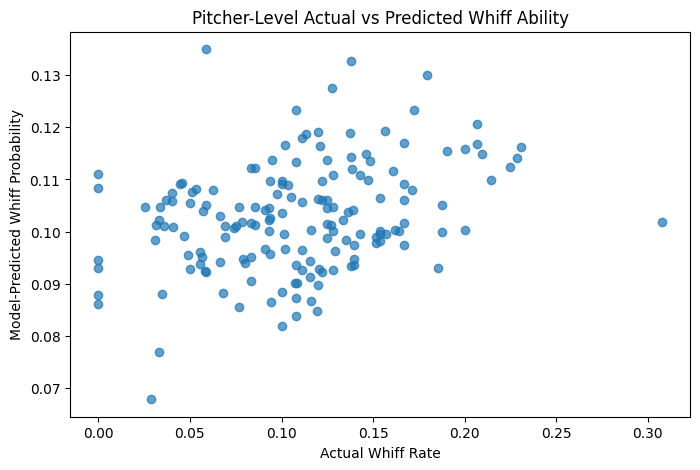

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(
    pitcher_insights["actual_whiff_rate"],
    pitcher_insights["predicted_whiff_probability"],
    alpha=0.7
)
plt.xlabel("Actual Whiff Rate")
plt.ylabel("Model-Predicted Whiff Probability")
plt.title("Pitcher-Level Actual vs Predicted Whiff Ability")
plt.show()


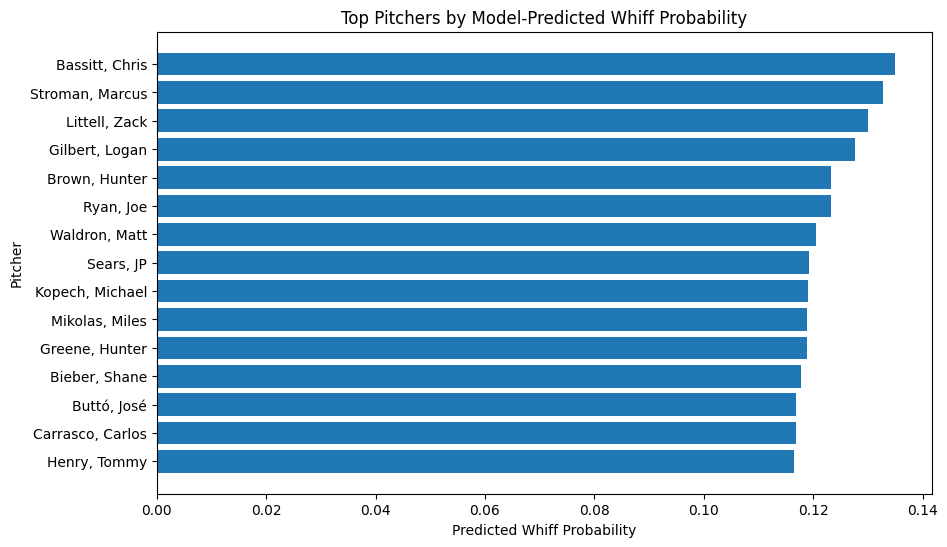

In [41]:
top_model_whiff_pitchers = pitcher_insights.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_model_whiff_pitchers["player_name"],
    top_model_whiff_pitchers["predicted_whiff_probability"]
)
plt.xlabel("Predicted Whiff Probability")
plt.ylabel("Pitcher")
plt.title("Top Pitchers by Model-Predicted Whiff Probability")
plt.gca().invert_yaxis()
plt.show()


## 13. Interpreting Results

1. **Pitch type prediction** shows whether the model can learn pitch-shape signatures from tracking features.
2. **Whiff prediction** estimates pitch effectiveness from the same sensor-derived inputs.
3. **Pitcher-level aggregation** turns pitch-level predictions into player evaluation insights.
4. The model can be extended with batter handedness, pitcher handedness, sequencing features, release-angle features, or video/tracking embeddings.
5. This framework could support pitch design, player development, advance scouting, and acquisition analysis.


## 14. Conclusion

This project demonstrates how MLB Statcast tracking data can be used with PyTorch to create a practical baseball analytics model.

The model learns from sensor-derived pitch characteristics and produces two useful outputs:

- A pitch type classification
- A whiff probability estimate

The project connects directly to baseball operations use cases such as pitcher evaluation, pitch design, and player development. Future improvements could include:

- More seasons of data
- Batter and pitcher handedness
- Pitch sequencing features
- Pitcher-specific embeddings
- Attention-based models over pitch sequences
- Integration of video-derived features
- Simulation of pitch mix changes

This notebook is intended to be a strong GitHub portfolio project for baseball analytics, sports data science, and machine learning roles.


## GitHub README Summary

**MLB Pitch Sensor Modeling with PyTorch**

This project uses MLB Statcast tracking data to build a multi-task PyTorch neural network for pitch type classification and whiff probability modeling. The model uses sensor-derived pitch features including velocity, spin rate, release position, movement, acceleration, and plate location.

The goal is to show how machine learning can convert complex baseball tracking data into actionable player evaluation insights. The final notebook includes data collection, cleaning, feature engineering, PyTorch model training, model evaluation, and pitcher-level analysis.
